In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
import plotly.express as px
from scipy.signal import find_peaks

In [123]:
# custom functions to perfomr Leq and db sum
def sum_levels(levels):
    l = np.array(levels)
    return 10*np.log10(np.sum(np.power(10,l/10)))

def leq(levels):
    l = np.array(levels)
    return 10*np.log10(np.mean(np.power(10,l/10)))

In [124]:
# opne csv file
csv_file = r"\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\5-Resultados\P1_CONTENEDORES\AI_MODEL\SPL_PREDICTIONS\P1_CONTENEDORES_v1_1_test.csv"
df = pd.read_csv(csv_file)
df

,filename,timestamp,LA,LC,LZ,LAmax,LAmin,class,probability
0,20231217_002245.WAV,2023-12-17 00:22:45,67.23,72.73,72.88,68.28,66.41,NaN,NaN
1,20231217_002245.WAV,2023-12-17 00:22:46,67.92,73.49,73.69,69.05,66.62,Vehicle,0.4445
2,20231217_002245.WAV,2023-12-17 00:22:47,68.61,74.57,74.87,69.70,67.88,Vehicle,0.6117
3,20231217_002245.WAV,2023-12-17 00:22:48,71.78,77.20,77.56,72.73,70.88,Vehicle,0.5862
4,20231217_002245.WAV,2023-12-17 00:22:49,74.63,80.07,80.37,76.86,72.06,Vehicle,0.3977
...,...,...,...,...,...,...,...,...,...
445,20231217_002245.WAV,2023-12-17 00:30:10,63.98,68.85,68.93,64.74,62.54,NaN,NaN
446,20231217_002245.WAV,2023-12-17 00:30:11,64.22,69.00,69.08,64.76,63.24,Vehicle,0.3293
447,20231217_002245.WAV,2023-12-17 00:30:12,64.23,68.91,69.00,64.96,63.53,NaN,NaN
448,20231217_002245.WAV,2023-12-17 00:30:13,65.51,70.07,70.16,66.47,64.88,NaN,NaN


In [130]:
# convert timestamp to datetime and calculate how long the measurement lasted
df['timestamp'] = pd.to_datetime(df['timestamp'])

# calculate the duration of the measurement
duration = df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]
duration = duration.total_seconds()
duration
print(f"Duration of the measurement: {duration} seconds, {duration/60} minutes")


Duration of the measurement: 449.0 seconds, 7.483333333333333 minutes


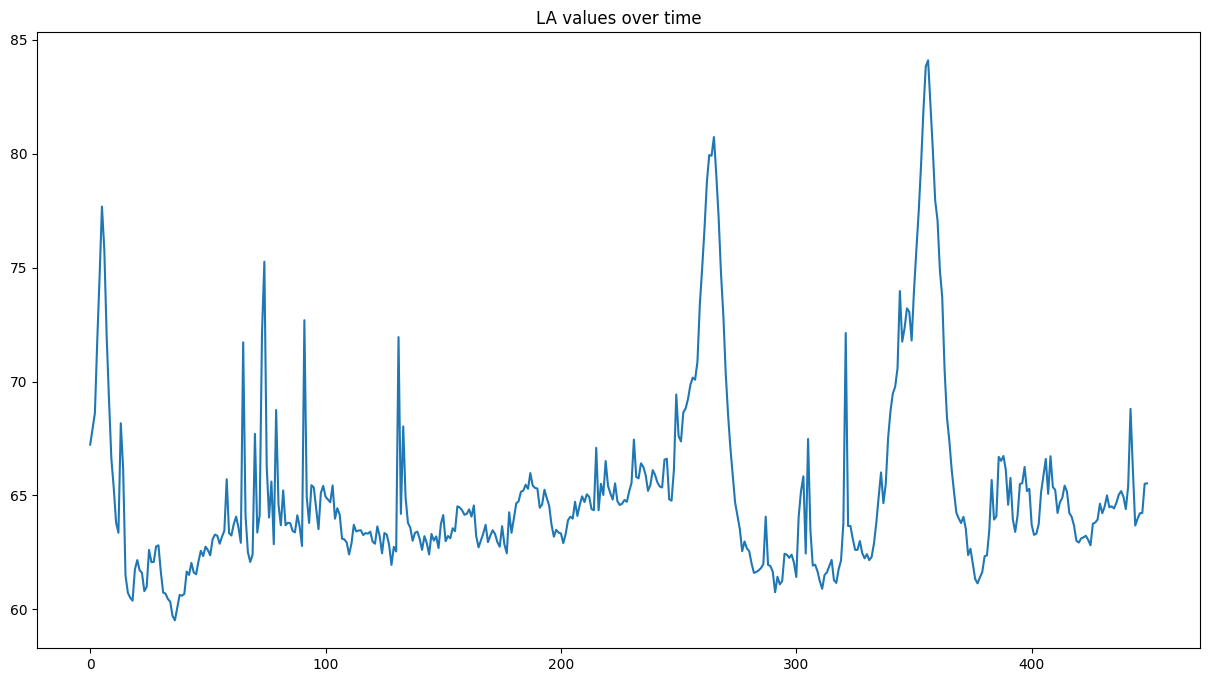

In [140]:
# plot LA column values over time
figure = plt.figure(figsize=(15, 8))
plt.plot(df['LA'])
plt.title('LA values over time')
plt.show()

In [141]:
la = df['LA'].values
print('Max:', np.max(la).round(2))
print('Min:', np.min(la).round(2))

print('\nMediana:', np.median(la).round(2))
print('Promedio:', leq(la).round(2))
print('Standard deviation:', np.std(la).round(2))

print('\nPercentil 98:', np.quantile(la, 0.99).round(2)) # Percentil 98 means that 98% of the data is below this value

Max: 84.1
Min: 59.52

Mediana: 64.06
Promedio: 68.94
Standard deviation: 4.07

Percentil 98: 80.46


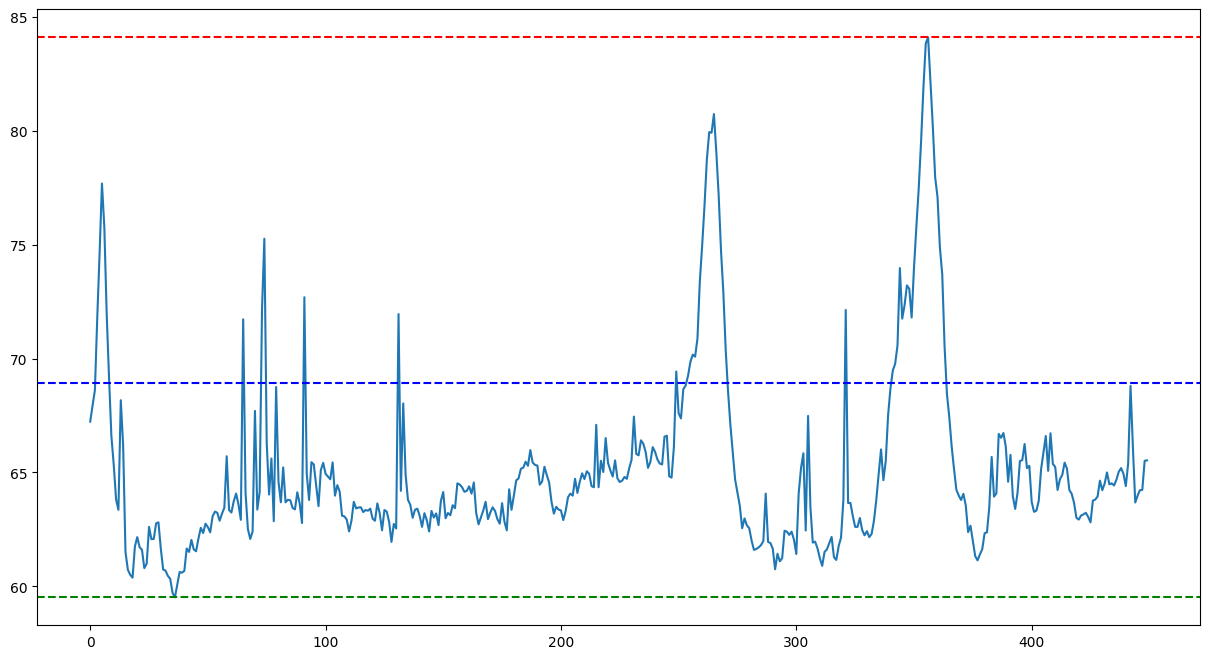

In [86]:
# print continuous lines over the la values for Max, min and mean
figure = plt.figure(figsize=(15, 8))
plt.plot(df['LA'])
plt.axhline(np.max(la), color='r', linestyle='--')
plt.axhline(np.min(la), color='g', linestyle='--')
plt.axhline(leq(la), color='b', linestyle='--')
plt.show()

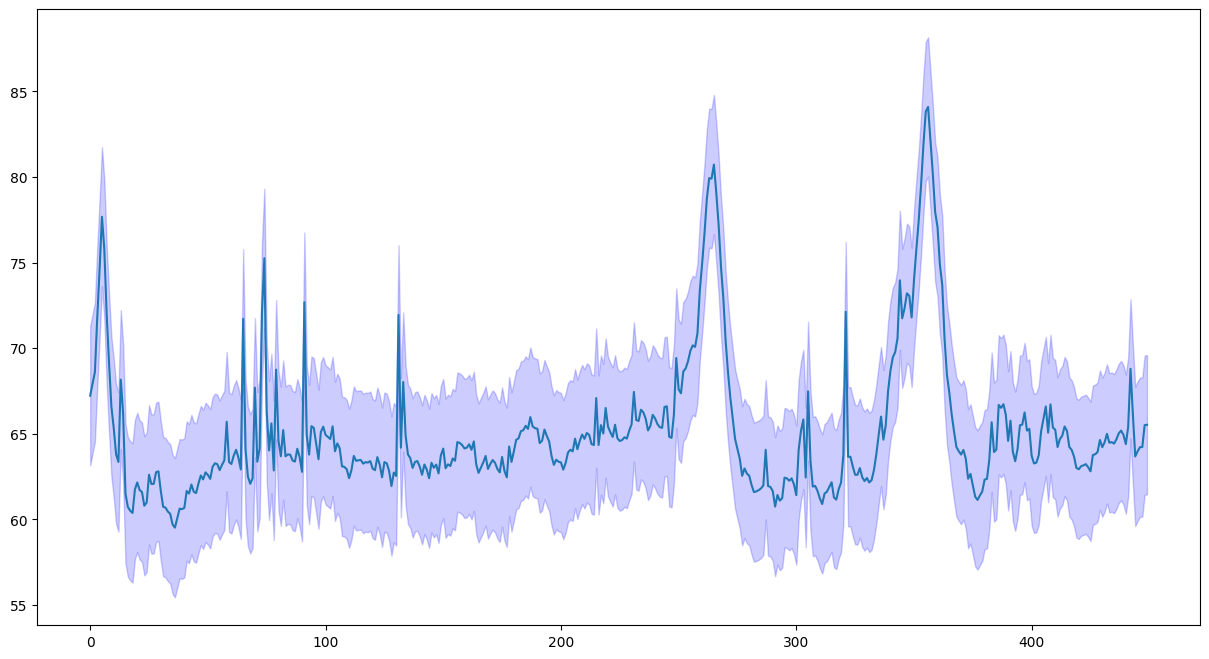

In [14]:
#plot standar deviation
figure = plt.figure(figsize=(15, 8))
plt.plot(df['LA'])
plt.fill_between(df.index, la - np.std(la), la + np.std(la), color='b', alpha=0.2)
plt.show()

# Peak detection for Port Environment

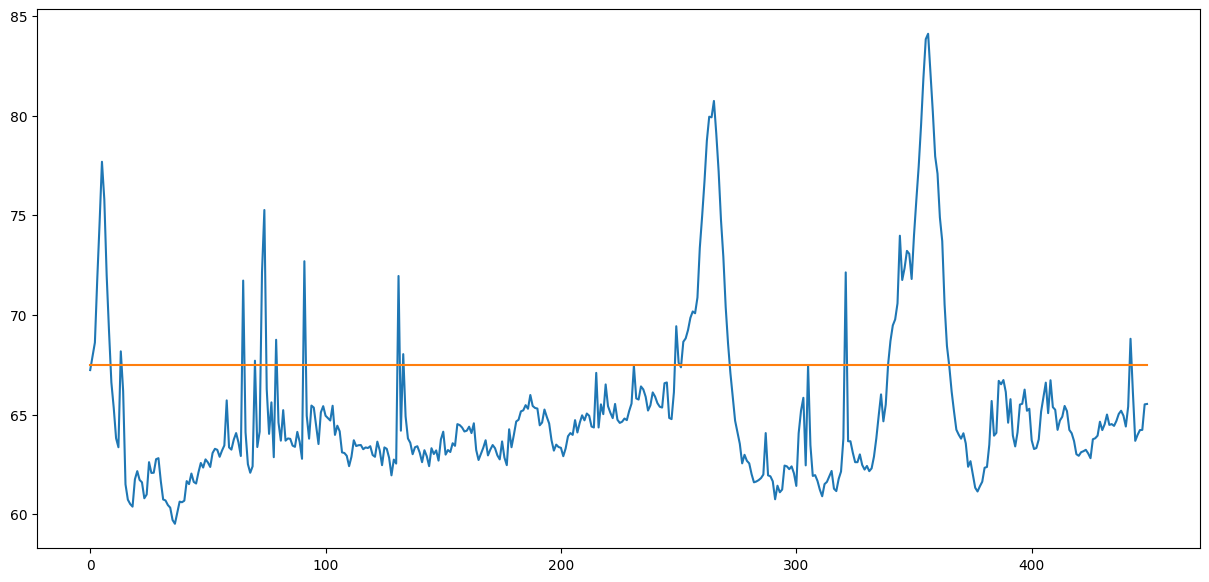

In [29]:
la = df.LA.values
l99 = np.quantile(la, 0.85)
umbral = l99 * np.ones([1, len(la)])

plt.figure(figsize=(15,7))
plt.plot(la)
plt.plot(umbral[0])

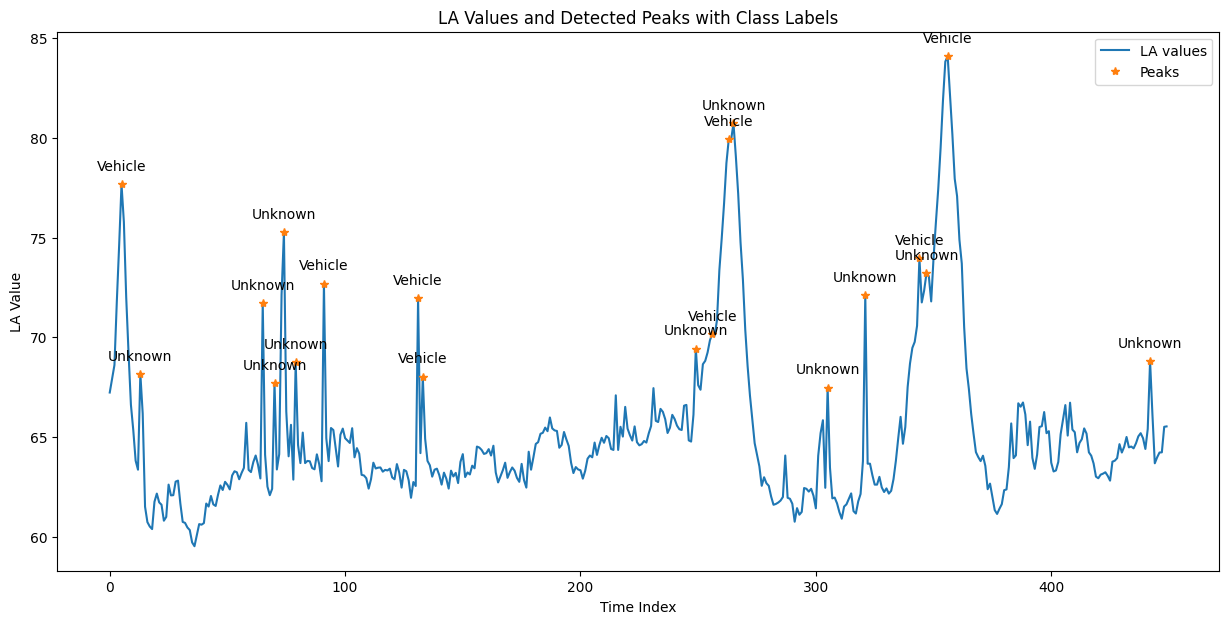

In [21]:
la = df['LA'].values
threshold = np.quantile(la, 0.85)

#peaks above the threshold
peak_idx, peak_dict = signal.find_peaks(la, height=threshold)
peak_values = la[peak_idx]

# la values and the detected peaks
plt.figure(figsize=(15, 7))
plt.plot(la, label='LA values')
plt.plot(peak_idx, peak_values, '*', label='Peaks')

#peaks with class labels or "Unknown"
for i, idx in enumerate(peak_idx):
    label = df['class'][idx]
    if pd.isna(label):  
        label = "Unknown"
    plt.annotate(label, (idx, la[idx]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('LA Values and Detected Peaks with Class Labels')
plt.xlabel('Time Index')
plt.ylabel('LA Value')
plt.legend()
plt.show()

# Other approach

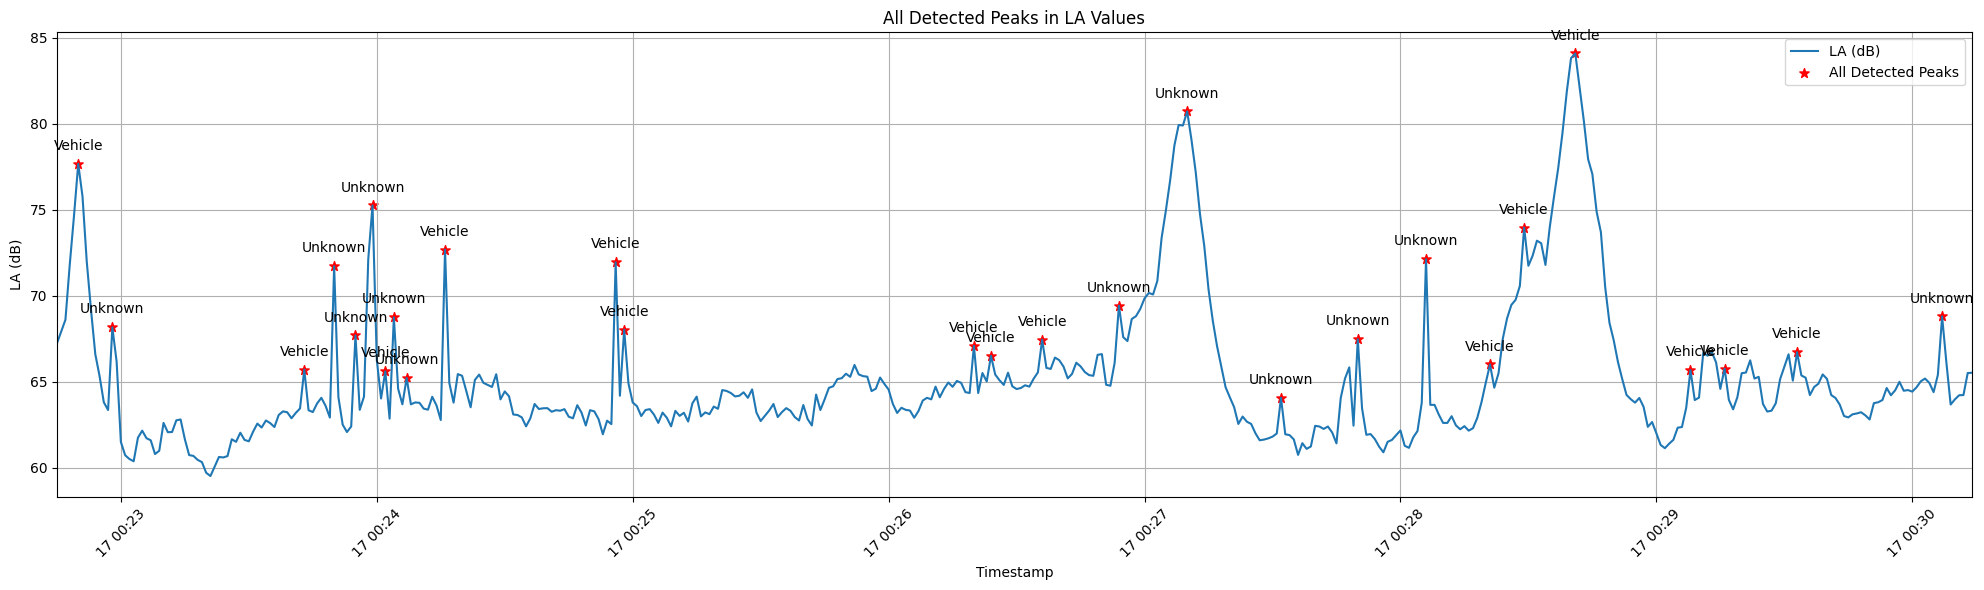

Number of peaks: 27


In [115]:
csv_file = r"\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\5-Resultados\P1_CONTENEDORES\AI_MODEL\SPL_PREDICTIONS\P1_CONTENEDORES_v1_1_test.csv"
df = pd.read_csv(csv_file)
df['timestamp'] = pd.to_datetime(df['timestamp'])

x = df['timestamp']
y = df['LA'].values

# [1] pass with the original parameters
peaks1 = find_peaks(y, height=1, threshold=1, distance=1)
peaks1_values = y[peaks1[0]]
peaks1_times = df['timestamp'][peaks1[0]]

# [2] pass with the adjusted parameters for higher peaks
peaks2 = find_peaks(y, height=70, prominence=5, distance=20)
peaks2_values = y[peaks2[0]]
peaks2_times = df['timestamp'][peaks2[0]]

# merging the peaks from both passes by their times
all_peaks_times = np.union1d(peaks1_times.astype(str), peaks2_times.astype(str))
all_peaks_indices = df.index[df['timestamp'].astype(str).isin(all_peaks_times)].tolist()
all_peaks_values = y[all_peaks_indices]


# plotting section
plt.figure(figsize=(20, 6))
plt.plot(df['timestamp'], y, label='LA (dB)')
plt.scatter(df['timestamp'][all_peaks_indices], all_peaks_values, color='r', s=50, marker='*', label='All Detected Peaks')

# plotting the names of the classes for the detected peaks
for i, idx in enumerate(all_peaks_indices):
    label = df['class'][idx]
    if pd.isna(label):  
        label = "Unknown"
    plt.annotate(label, (df['timestamp'][idx], all_peaks_values[i]), textcoords="offset points", xytext=(0,10), ha='center')

# remove blank spaces from the beginning and end of the plot
plt.xlim(df['timestamp'].iloc[0], df['timestamp'].iloc[-1])
plt.title('All Detected Peaks in LA Values')
plt.xlabel('Timestamp')
plt.ylabel('LA (dB)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# print how many peaks were detected
print('Number of peaks:', len(all_peaks_indices))

# plotting label

In [116]:
csv_file = r"\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\5-Resultados\P1_CONTENEDORES\AI_MODEL\SPL_PREDICTIONS\P1_CONTENEDORES_v1_1_test.csv"
df_all = pd.read_csv(csv_file)
df_all['timestamp'] = pd.to_datetime(df_all['timestamp'])


gap_threshold = pd.Timedelta(seconds=1)
fig = px.line(df_all, x='timestamp', y='LA', title='LA Values Over Time')

unique_classes = df_all['class'].dropna().unique()
for unique_class in unique_classes:
    df_class = df_all[(df_all['class'] == unique_class)].sort_values('timestamp')
    
    df_class['time_diff'] = df_class['timestamp'].diff()
    df_class.loc[df_class['time_diff'] > gap_threshold, 'LA'] = None
    fig.add_scatter(x=df_class['timestamp'], y=df_class['LA'], mode='lines', name=unique_class)


# fig.update_layout(width=2500, height=1100)
fig.update_layout(title_text='LA Values and Classes Over Time')
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='LA')

fig.show()

print(f"Unique classes: {len(unique_classes)}")
print(unique_classes)

Unique classes: 5
['Vehicle' 'Speech' 'Vehicle, Aircraft' 'Rail transport, Train, Vehicle'
 'Chant']


In [109]:
csv_file = r"\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\5-Resultados\P1_CONTENEDORES\AI_MODEL\SPL_PREDICTIONS\P1_CONTENEDORES_v1_1_test.csv"
df = pd.read_csv(csv_file)
df['timestamp'] = pd.to_datetime(df['timestamp'])

y = df['LA'].values
peaks1 = find_peaks(y, height=1, threshold=1, distance=1)
peaks2 = find_peaks(y, height=70, prominence=5, distance=20)

all_peaks_indices = np.unique(np.concatenate((peaks1[0], peaks2[0])))

df['highlight'] = False
df.loc[all_peaks_indices, 'highlight'] = True

fig = px.line(df, x='timestamp', y='LA', title='LA Values Over Time', color_discrete_sequence=['blue'])

fig.add_scatter(x=df['timestamp'][all_peaks_indices], y=df['LA'][all_peaks_indices], mode='markers', marker=dict(color='red', size=8), name='Detected Peaks')

for idx in all_peaks_indices:
    class_label = df.loc[idx, 'class'] if pd.notna(df.loc[idx, 'class']) else 'Unknown'
    fig.add_annotation(x=df.loc[idx, 'timestamp'], y=df.loc[idx, 'LA'],
                       text=class_label, showarrow=True, arrowhead=1, arrowsize=2, arrowwidth=1, arrowcolor='red')

fig.update_layout(showlegend=True)
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='LA')
fig.show()

print('Number of peaks:', len(all_peaks_indices))

Number of peaks: 27


In [120]:
csv_file = r"\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\5-Resultados\P1_CONTENEDORES\AI_MODEL\SPL_PREDICTIONS\P1_CONTENEDORES_v1_1_test.csv"
df_all = pd.read_csv(csv_file)
df_all['timestamp'] = pd.to_datetime(df_all['timestamp'])


# peaks detections with two passes
y = df_all['LA'].values
peaks1 = find_peaks(y, height=1, threshold=1, distance=1)
peaks2 = find_peaks(y, height=70, prominence=5, distance=20)
all_peaks_indices = np.unique(np.concatenate((peaks1[0], peaks2[0])))


# initialize the main figure
fig = px.line(df_all, x='timestamp', y='LA', title='LA Values Over Time')


# colored by class
unique_classes = df_all['class'].dropna().unique()
gap_threshold = pd.Timedelta(seconds=1)
for unique_class in unique_classes:
    df_class = df_all[(df_all['class'] == unique_class)].sort_values('timestamp')
    df_class['time_diff'] = df_class['timestamp'].diff()
    df_class.loc[df_class['time_diff'] > gap_threshold, 'LA'] = None  # reset LA to none if gap exceeds threshold
    fig.add_scatter(x=df_class['timestamp'], y=df_class['LA'], mode='lines', name=unique_class)


#plot for all peaks
peak_times = df_all['timestamp'][all_peaks_indices]
peak_values = df_all['LA'][all_peaks_indices]
fig.add_scatter(x=peak_times, y=peak_values, mode='markers', marker=dict(color='red', size=8), name='Detected Peaks')


# peaks with class labels
for idx in all_peaks_indices:
    class_label = df_all.loc[idx, 'class'] if pd.notna(df_all.loc[idx, 'class']) else 'Unknown'
    fig.add_annotation(x=df_all.loc[idx, 'timestamp'], y=df_all.loc[idx, 'LA'],
                       text=class_label, showarrow=True, arrowhead=1, arrowsize=2, arrowwidth=1, arrowcolor='red')


min_timestamp = df_all['timestamp'].min()
max_timestamp = df_all['timestamp'].max()
fig.update_xaxes(range=[min_timestamp, max_timestamp])


fig.update_layout(title_text='LA Values and Classes Over Time')
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='LA')
fig.show()

print(f"Unique classes: {len(unique_classes)}")
print(unique_classes)

Unique classes: 5
['Vehicle' 'Speech' 'Vehicle, Aircraft' 'Rail transport, Train, Vehicle'
 'Chant']
